In [2]:
"""
Chi-elevation plots and inversion for RP-S2 vs RP-S3
Modular version with separate analysis blocks and configurable options
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/mnt/project')

from TopoAnalysis import dem as d

# Add FluvialLandformInversion to path
sys.path.insert(0, '/Users/Glong1/Desktop/Andes/AndesTG/FluvialLandformInversion_master/python')

from fluvial_inversion import (
    prepare_inversion_data, 
    findm_slope_area, 
    calculate_chi, 
    invert_block_uplift,
    invert_with_different_gamma,
    calibrate_k_total_uplift,
    bootstrap_invert_block_uplift
)

In [3]:
# CONFIGURATION - EDIT HERE

SAVE_PLOTS = False  # Set to True to save figures
OUTPUT_DIR = '/mnt/user-data/outputs/'

THETA = 0.55
A_REF = 1e6
MIN_AREA = 1e6

GAMMA = 1.0
Q = 10

main_outlet = (240012.37420, 6244480.71900)
outlets = {
    'RP-S2': (246249.2076, 6240448.447),
    'RP-S3': (250212.9354, 6237948.848)
}

In [4]:
# LOAD DATA (RUN ONCE)

print("Loading DEM data...")
area = d.Area.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/rapel_area_utm30m')
fd = d.FlowDirectionD8.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/rapel_fd_utm30m')
elevation = d.Elevation.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/rapel_SRTMGL130m_dem_utm.tif')
print("Data loaded\n")

chi_main = d.Chi(flow_direction=fd, area=area, theta=THETA, Ao=A_REF, outlets=[main_outlet])
chi_main_data = chi_main._griddata
elev_data = elevation._griddata
area_data = area._griddata

Loading DEM data...
Data loaded



In [32]:
# BLOCK 1: EXTRACT WATERSHEDS

def extract_watersheds():
    """Extract chi and elevation for both basins, filtered by area threshold"""
    
    sample_data = {}
    overall_chi_min = np.inf
    overall_chi_max = 0
    
    for sample_name in ['RP-S2', 'RP-S3']:
        print(f"Processing {sample_name}...")
        outlet = outlets[sample_name]
        
        # Calculate chi for this sample's watershed
        chi_sample_grid = d.Chi(flow_direction=fd, area=area, theta=THETA, Ao=A_REF, outlets=[outlet])
        chi_sample_data = chi_sample_grid._griddata
        
        # Mask: watershed + area threshold
        mask_watershed = chi_sample_data > 0
        mask_area = area_data >= MIN_AREA
        mask_combined = mask_watershed & mask_area
        
        # Extract using main outlet chi scale
        chi_masked = chi_main_data[mask_combined]
        elev_masked = elev_data[mask_combined]
        
        # Remove NaNs
        valid = ~np.isnan(chi_masked) & ~np.isnan(elev_masked)
        chi_sample = chi_masked[valid]
        elev_sample = elev_masked[valid]
        
        chi_min = np.min(chi_sample)
        chi_max = np.max(chi_sample)
        overall_chi_min = min(overall_chi_min, chi_min)
        overall_chi_max = max(overall_chi_max, chi_max)
        
        sample_data[sample_name] = {
            'chi': chi_sample,
            'elev': elev_sample,
            'chi_min': chi_min,
            'chi_max': chi_max,
            'm': THETA
        }
        
        print(f"  m = {THETA:.4f} (using THETA directly)")
        print(f"  Points: {len(chi_sample)}")
        print(f"  Chi range: {chi_min:.1f} - {chi_max:.1f} m")
        print(f"  Elevation range: {np.min(elev_sample):.1f} - {np.max(elev_sample):.1f} m\n")
    
    return sample_data, overall_chi_min, overall_chi_max

# ============================================================================
# BLOCK 2: PLOT CHI-ELEVATION

def plot_chi_elevation(sample_data, overall_chi_min, overall_chi_max):
    """Plot chi-elevation overlay for both basins"""
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = {'RP-S2': 'red', 'RP-S3': 'blue'}
    
    for sample_name in ['RP-S2', 'RP-S3']:
        chi_sample = sample_data[sample_name]['chi']
        elev_sample = sample_data[sample_name]['elev']
        ax.scatter(chi_sample, elev_sample, s=2, alpha=0.6, 
                  label=sample_name, c=colors[sample_name])
    
    ax.set_xlabel('χ (m)', fontsize=12)
    ax.set_ylabel('Elevation (m)', fontsize=12)
    ax.set_title('Chi-Elevation: RP-S2 (Equilibrated) vs RP-S3 (Unequilibrated)', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(overall_chi_min * 0.95, overall_chi_max * 1.05)
    
    plt.tight_layout()
    
    if SAVE_PLOTS:
        plt.savefig(OUTPUT_DIR + 'chi_elevation_RP_S2_vs_S3.png', dpi=150, bbox_inches='tight')
        print("Saved: chi_elevation_RP_S2_vs_S3.png\n")
    
    plt.show()

# ============================================================================
# BLOCK 3: BASIC INVERSION (first pass)

def invert_uplift_histories(sample_data):
    """Invert both basins for uplift rate histories"""
    
    print("=" * 70)
    print("INVERTING FOR UPLIFT HISTORIES")
    print("=" * 70)
    print(f"Damping coefficient (Gamma): {GAMMA}")
    print(f"Number of time intervals (q): {Q}\n")
    
    inversion_results = {}
    
    for sample_name in ['RP-S2', 'RP-S3']:
        print(f"Inverting {sample_name}...")
        
        chi = sample_data[sample_name]['chi']
        z = sample_data[sample_name]['elev']
        
        # Sort by chi
        idx = np.argsort(chi)
        chi = chi[idx]
        z = z[idx]
        
        Ustar, tstar, misfit = invert_block_uplift(
            chi=chi, z=z, gamma=GAMMA, q=Q
        )
        
        inversion_results[sample_name] = {
            'Ustar': Ustar,
            'tstar': tstar,
            'misfit': misfit,
            'chi': chi,
            'z': z
        }
        
        print(f"  Misfit: {misfit:.4f} m")
        print(f"  Uplift range: [{np.min(Ustar):.4e}, {np.max(Ustar):.4e}] m/m_chi\n")
    
    return inversion_results

# ============================================================================
# BLOCK 4: PLOT UPLIFT HISTORIES

def plot_uplift_histories(inversion_results):
    """Plot inferred uplift rate histories"""
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = {'RP-S2': 'red', 'RP-S3': 'blue'}
    
    for sample_name in ['RP-S2', 'RP-S3']:
        Ustar = inversion_results[sample_name]['Ustar']
        tstar = inversion_results[sample_name]['tstar']
        
        ax.step(tstar[:-1], Ustar, where='post', linewidth=2, 
               label=sample_name, color=colors[sample_name])
    
    ax.set_xlabel('Scaled Time χ* (m)', fontsize=12)
    ax.set_ylabel('Scaled Uplift Rate U* (m/m)', fontsize=12)
    ax.set_title('Inferred Uplift Histories (Non-dimensional)', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    
    plt.tight_layout()
    
    if SAVE_PLOTS:
        plt.savefig(OUTPUT_DIR + 'uplift_histories_comparison.png', dpi=150, bbox_inches='tight')
        print("Saved: uplift_histories_comparison.png\n")
    
    plt.show()

# ============================================================================
# BLOCK 5: L-CURVE ANALYSIS (Find optimal gamma)

def find_optimal_gamma(sample_data, gamma_range=None):
    """
    Run L-curve analysis to find optimal regularization parameter.
    Plots misfit vs roughness for each basin.
    """
    
    if gamma_range is None:
        gamma_range = np.logspace(-1, 3, 50)  # 0.1 to 1000
    
    print("=" * 70)
    print("L-CURVE ANALYSIS - Finding Optimal Gamma")
    print("=" * 70)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {'RP-S2': 'red', 'RP-S3': 'blue'}
    
    optimal_gammas = {}
    
    for idx, sample_name in enumerate(['RP-S2', 'RP-S3']):
        print(f"\nAnalyzing {sample_name}...")
        
        chi = sample_data[sample_name]['chi']
        z = sample_data[sample_name]['elev']
        
        # Sort by chi
        sort_idx = np.argsort(chi)
        chi = chi[sort_idx]
        z = z[sort_idx]
        
        # Run inversion for each gamma
        misfits = []
        roughness = []
        
        for gamma in gamma_range:
            Ustar, tstar, misfit = invert_block_uplift(chi=chi, z=z, gamma=gamma, q=Q)
            misfits.append(misfit)
            
            # Roughness = sum of squared differences in uplift rates
            rough = np.sum(np.diff(Ustar)**2)
            roughness.append(rough)
        
        misfits = np.array(misfits)
        roughness = np.array(roughness)
        
        # Plot L-curve
        ax = axes[idx]
        ax.loglog(misfits, roughness, 'o-', color=colors[sample_name], linewidth=2, markersize=4)
        ax.set_xlabel('Data Misfit (m)', fontsize=11)
        ax.set_ylabel('Model Roughness', fontsize=11)
        ax.set_title(f'{sample_name} L-Curve', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, which='both')
        
        # Find elbow (steepest part of curve)
        log_misfit = np.log10(misfits)
        log_rough = np.log10(roughness)
        curvature = np.abs(np.diff(log_rough) / np.diff(log_misfit))
        elbow_idx = np.argmax(curvature)
        
        optimal_gamma = gamma_range[elbow_idx]
        optimal_gammas[sample_name] = optimal_gamma
        
        # Mark elbow on plot
        ax.plot(misfits[elbow_idx], roughness[elbow_idx], 'r*', markersize=20, 
               label=f'Elbow: γ={optimal_gamma:.2f}')
        ax.legend(fontsize=10)
        
        print(f"  Optimal gamma (at elbow): {optimal_gamma:.4f}")
    
    plt.tight_layout()
    
    if SAVE_PLOTS:
        plt.savefig(OUTPUT_DIR + 'lcurve_analysis.png', dpi=150, bbox_inches='tight')
        print("\nSaved: lcurve_analysis.png")
    
    plt.show()
    
    return optimal_gammas

# ============================================================================
# BLOCK 6: BOOTSTRAP UNCERTAINTY ANALYSIS

def bootstrap_analysis(sample_data, optimal_gammas, n_iterations=100):
    """
    Run bootstrap analysis to quantify uncertainty in inferred uplift rates.
    """
    
    print("\n" + "=" * 70)
    print("BOOTSTRAP UNCERTAINTY ANALYSIS")
    print("=" * 70)
    print(f"Running {n_iterations} iterations for each basin...\n")
    
    bootstrap_results = {}
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    colors = {'RP-S2': 'red', 'RP-S3': 'blue'}
    
    for idx, sample_name in enumerate(['RP-S2', 'RP-S3']):
        print(f"Bootstrap {sample_name}...")
        
        chi = sample_data[sample_name]['chi']
        z = sample_data[sample_name]['elev']
        
        # Sort by chi
        sort_idx = np.argsort(chi)
        chi = chi[sort_idx]
        z = z[sort_idx]
        
        gamma = optimal_gammas[sample_name]
        
        # Run bootstrap
        Ustar_mat, tstar = bootstrap_invert_block_uplift(
            chi=chi, z=z, gamma=gamma, q=Q, 
            percent_sample=0.8, num_iterations=n_iterations, to_plot=False
        )
        
        # Calculate mean and std
        Ustar_mean = np.mean(Ustar_mat, axis=0)
        Ustar_std = np.std(Ustar_mat, axis=0)
        
        bootstrap_results[sample_name] = {
            'Ustar_mat': Ustar_mat,
            'tstar': tstar,
            'Ustar_mean': Ustar_mean,
            'Ustar_std': Ustar_std
        }
        
        # Plot
        ax = axes[idx]
        
        # Plot all realizations (gray)
        for i in range(n_iterations):
            ax.step(tstar[:-1], Ustar_mat[i], where='post', alpha=0.01, color='gray', linewidth=0.5)
        
        # Plot mean (thick line)
        ax.step(tstar[:-1], Ustar_mean, where='post', color=colors[sample_name], 
               linewidth=2.5, label='Mean')
        
        # Plot ±1σ bounds (dashed)
        ax.step(tstar[:-1], Ustar_mean + Ustar_std, where='post', 
               color=colors[sample_name], linewidth=1, linestyle='--', alpha=0.7)
        ax.step(tstar[:-1], Ustar_mean - Ustar_std, where='post', 
               color=colors[sample_name], linewidth=1, linestyle='--', alpha=0.7, 
               label='±1σ')
        
        ax.set_xlabel('Scaled Time χ* (m)', fontsize=11)
        ax.set_ylabel('Scaled Uplift Rate U* (m/m)', fontsize=11)
        ax.set_title(f'{sample_name} (γ={gamma:.2f}, n={n_iterations})', 
                    fontsize=12, fontweight='bold')
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
    
    plt.tight_layout()
    
    if SAVE_PLOTS:
        plt.savefig(OUTPUT_DIR + 'bootstrap_uncertainty.png', dpi=150, bbox_inches='tight')
        print("\nSaved: bootstrap_uncertainty.png")
    
    plt.show()
    
    return bootstrap_results

# ============================================================================
# BLOCK 7: SUMMARY

def print_summary(sample_data, inversion_results, overall_chi_min, overall_chi_max, bootstrap_results, optimal_gammas):
    """Print comprehensive analysis summary"""
    
    print("=" * 70)
    print("FINAL SUMMARY")
    print("=" * 70)
    
    print(f"\nDATASET:")
    print(f"  Overall chi range: {overall_chi_min:.1f} - {overall_chi_max:.1f} m")
    print(f"  Concavity (m): {THETA:.4f}")
    print(f"  Reference area (A0): {A_REF:.2e} m²")
    
    print(f"\n{'PARAMETER':<20} {'RP-S2':<25} {'RP-S3':<25}")
    print("-" * 70)
    
    print(f"{'Data points':<20} {len(sample_data['RP-S2']['chi']):<25} {len(sample_data['RP-S3']['chi']):<25}")
    print(f"{'Chi range (m)':<20} {sample_data['RP-S2']['chi_min']:.1f}-{sample_data['RP-S2']['chi_max']:.1f}          {sample_data['RP-S3']['chi_min']:.1f}-{sample_data['RP-S3']['chi_max']:.1f}")
    print(f"{'Elev range (m)':<20} {np.min(sample_data['RP-S2']['elev']):.1f}-{np.max(sample_data['RP-S2']['elev']):.1f}          {np.min(sample_data['RP-S3']['elev']):.1f}-{np.max(sample_data['RP-S3']['elev']):.1f}")
    
    print(f"\n{'INVERSION (γ={GAMMA})':<20} {'RP-S2':<25} {'RP-S3':<25}")
    print("-" * 70)
    print(f"{'Misfit (m)':<20} {inversion_results['RP-S2']['misfit']:.4f}                  {inversion_results['RP-S3']['misfit']:.4f}")
    print(f"{'U* min (m/m)':<20} {np.min(inversion_results['RP-S2']['Ustar']):.4e}           {np.min(inversion_results['RP-S3']['Ustar']):.4e}")
    print(f"{'U* max (m/m)':<20} {np.max(inversion_results['RP-S2']['Ustar']):.4e}           {np.max(inversion_results['RP-S3']['Ustar']):.4e}")
    print(f"{'U* mean (m/m)':<20} {np.mean(inversion_results['RP-S2']['Ustar']):.4e}           {np.mean(inversion_results['RP-S3']['Ustar']):.4e}")
    
    print(f"\n{'BOOTSTRAP (n=100)':<20} {'RP-S2':<25} {'RP-S3':<25}")
    print("-" * 70)
    print(f"{'Optimal γ':<20} {optimal_gammas['RP-S2']:.4f}                  {optimal_gammas['RP-S3']:.4f}")
    print(f"{'U* mean ±std':<20} {bootstrap_results['RP-S2']['Ustar_mean'][0]:.4e} ± {bootstrap_results['RP-S2']['Ustar_std'][0]:.4e}     {bootstrap_results['RP-S3']['Ustar_mean'][0]:.4e} ± {bootstrap_results['RP-S3']['Ustar_std'][0]:.4e}")
    
    print(f"\n{'INTERPRETATION':<70}")
    print("-" * 70)
    print(f"RP-S2 (Equilibrated): Narrow, constant U* range → steady-state river")
    print(f"RP-S3 (Unequilibrated): Wide, variable U* range → transient response")
    print(f"                      Likely causes: uplift rate change, stream capture, or base level change")
    
    print("\n" + "=" * 70)

In [33]:
# Block 1: Extract data
sample_data, overall_chi_min, overall_chi_max = extract_watersheds()

Processing RP-S2...
  m = 0.5500 (using THETA directly)
  Points: 980
  Chi range: 172.8 - 4369.5 m
  Elevation range: 21.0 - 195.0 m

Processing RP-S3...
  m = 0.5500 (using THETA directly)
  Points: 4986
  Chi range: 101.6 - 5780.8 m
  Elevation range: 20.0 - 337.0 m



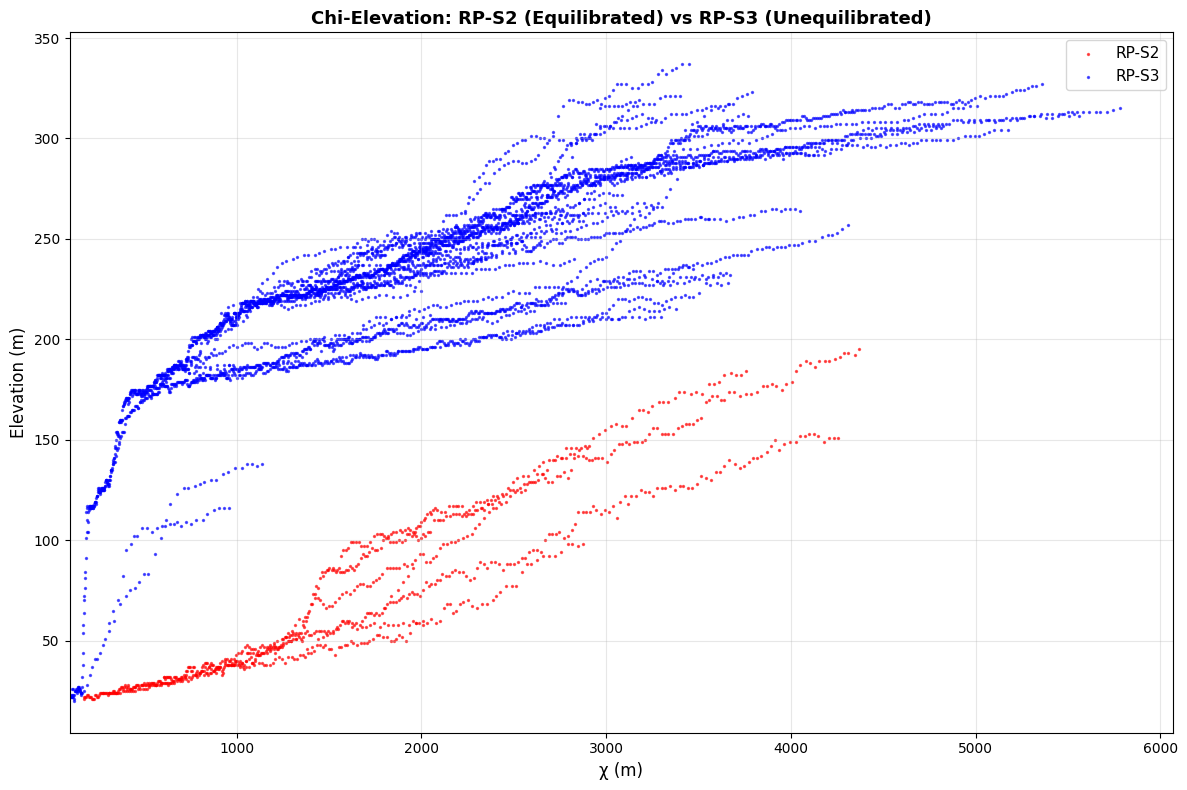

In [34]:
# Block 2: Plot chi-elevation
plot_chi_elevation(sample_data, overall_chi_min, overall_chi_max)

In [35]:
# Block 3: Basic inversion
inversion_results = invert_uplift_histories(sample_data)

INVERTING FOR UPLIFT HISTORIES
Damping coefficient (Gamma): 1.0
Number of time intervals (q): 10

Inverting RP-S2...
  Misfit: 0.4636 m
  Uplift range: [8.0744e-03, 6.0696e-02] m/m_chi

Inverting RP-S3...
  Misfit: 0.3346 m
  Uplift range: [-1.0991e-02, 2.8924e-01] m/m_chi



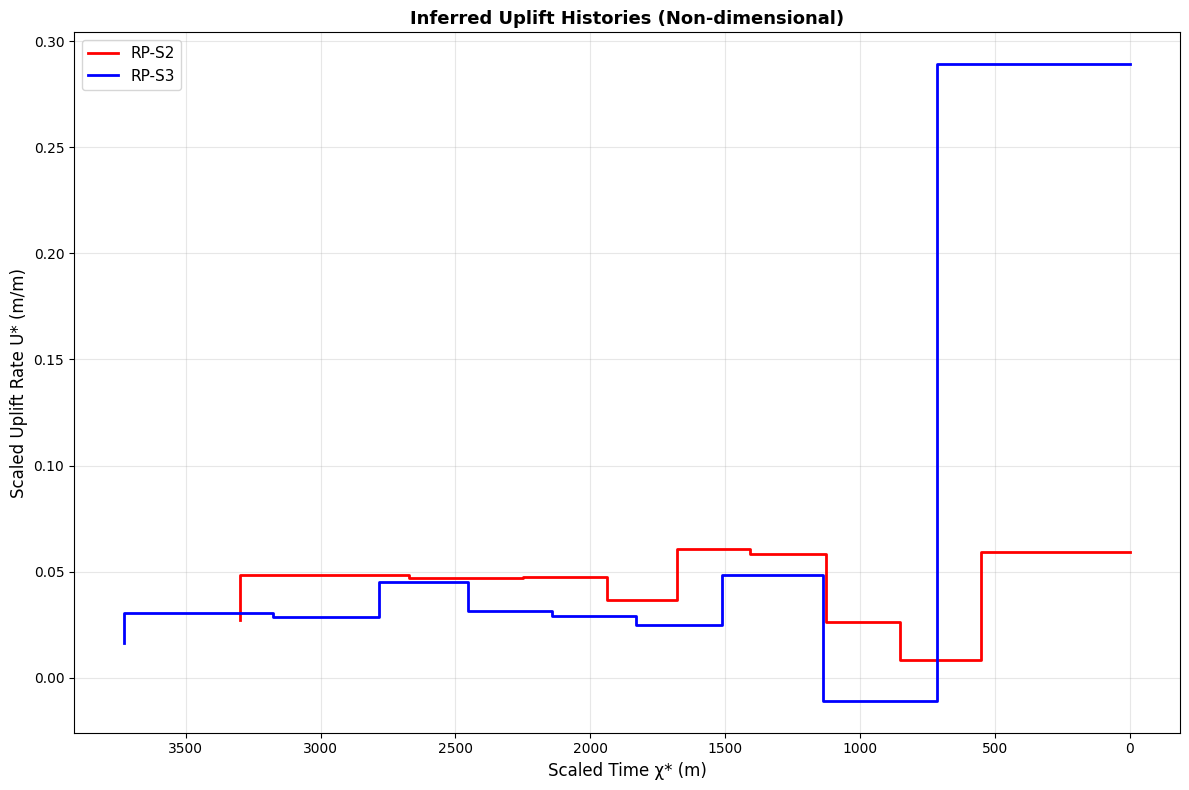

In [36]:
# Block 4: Plot uplift histories
plot_uplift_histories(inversion_results)

L-CURVE ANALYSIS - Finding Optimal Gamma

Analyzing RP-S2...


/var/folders/q2/0xd1lglj6lzdx_7wr72bt7t00000gp/T/ipykernel_45645/241291495.py:221: RuntimeWarning: divide by zero encountered in divide
  curvature = np.abs(np.diff(log_rough) / np.diff(log_misfit))


  Optimal gamma (at elbow): 0.1000

Analyzing RP-S3...
  Optimal gamma (at elbow): 0.1000


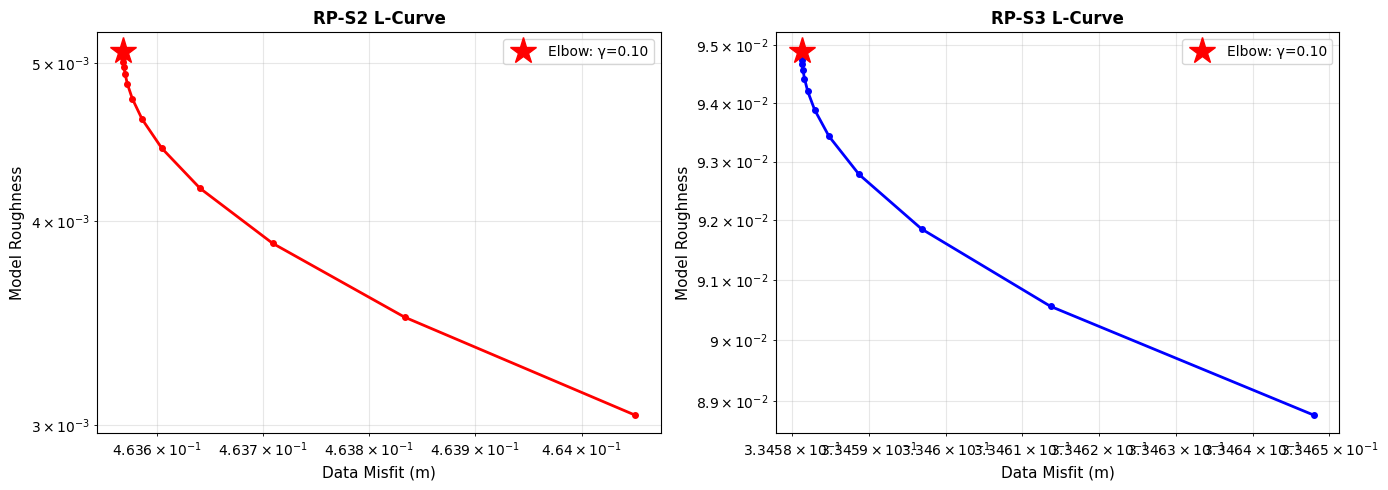

In [37]:
# Block 5: L-curve analysis
optimal_gammas = find_optimal_gamma(sample_data)


BOOTSTRAP UNCERTAINTY ANALYSIS
Running 100 iterations for each basin...

Bootstrap RP-S2...
Bootstrap RP-S3...


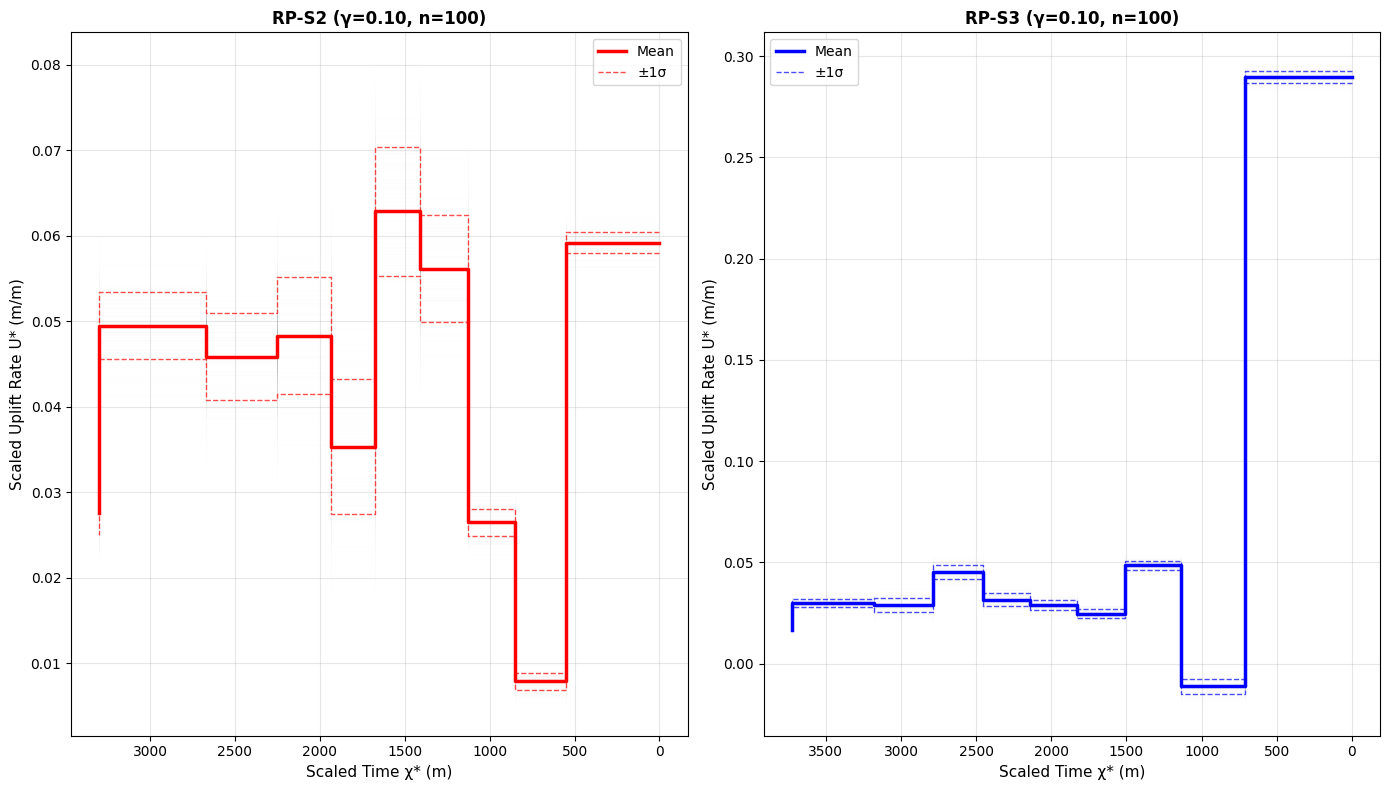

In [38]:
# Block 6: Bootstrap (100 iterations)
bootstrap_results = bootstrap_analysis(sample_data, optimal_gammas, n_iterations=100)

In [39]:
# Block 7: Summary
print_summary(sample_data, inversion_results, overall_chi_min, overall_chi_max, bootstrap_results, optimal_gammas)

FINAL SUMMARY

DATASET:
  Overall chi range: 101.6 - 5780.8 m
  Concavity (m): 0.5500
  Reference area (A0): 1.00e+06 m²

PARAMETER            RP-S2                     RP-S3                    
----------------------------------------------------------------------
Data points          980                       4986                     
Chi range (m)        172.8-4369.5          101.6-5780.8
Elev range (m)       21.0-195.0          20.0-337.0

INVERSION (γ={GAMMA}) RP-S2                     RP-S3                    
----------------------------------------------------------------------
Misfit (m)           0.4636                  0.3346
U* min (m/m)         8.0744e-03           -1.0991e-02
U* max (m/m)         6.0696e-02           2.8924e-01
U* mean (m/m)        4.1796e-02           5.3266e-02

BOOTSTRAP (n=100)    RP-S2                     RP-S3                    
----------------------------------------------------------------------
Optimal γ            0.1000                  0.100